In [3]:
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.plot import show

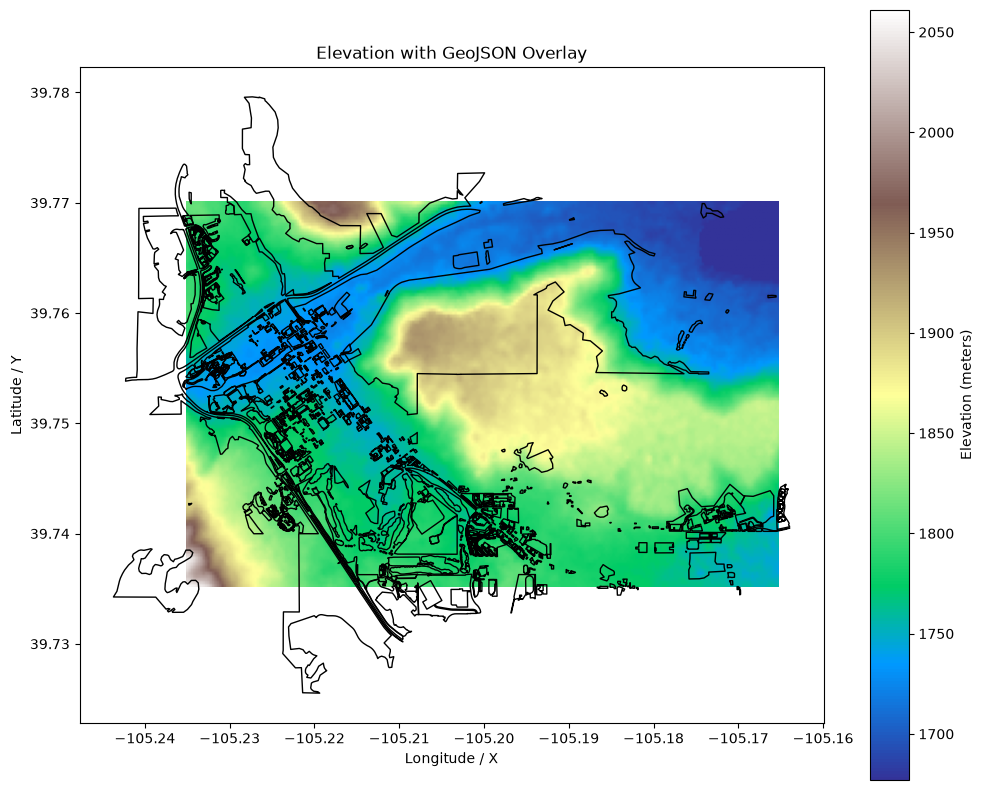

In [4]:
# Load elevation raster
with rasterio.open("elevation_raster_data.tif") as src:
    elevation = src.read(1)
    raster_extent = [
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top,
    ]
    raster_crs = src.crs

# Load GeoJSON
gdf = gpd.read_file("../exports/ghe_locations.geojson")

# Make sure GeoJSON uses the same CRS as the raster
if gdf.crs != raster_crs:
    gdf = gdf.to_crs(raster_crs)

# Create plot
fig, ax = plt.subplots(figsize=(12, 10))

# Display elevation
image = ax.imshow(
    elevation,
    extent=raster_extent,
    cmap="terrain",
    origin="upper"
)

# Overlay GeoJSON
gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.0
)

# Elevation legend/colorbar
cbar = fig.colorbar(image, ax=ax)
cbar.set_label("Elevation (meters)")

ax.set_xlabel("Longitude / X")
ax.set_ylabel("Latitude / Y")
ax.set_title("Elevation with GeoJSON Overlay")

plt.show()
